# Statistics for Decision Making - Assignment Solutions

Using **property.csv** (Australian real estate data).

**Requirements:** `pandas`, `numpy`, `matplotlib`, `scipy`, `statsmodels`.  
If needed: `pip install pandas numpy matplotlib scipy statsmodels`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

df = pd.read_csv('property.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-12-03,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-02-04,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-03-04,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-03-04,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-06-04,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


---
## Question 1: Altona – Typical property $800,000? Has it increased? (α = 5%)

In [2]:
altona = df[df['Suburb'] == 'Altona']['Price'].dropna()
mu0 = 800_000
alpha = 0.05

# One-sample t-test (two-tailed first); then one-tailed for "increased"
t_stat, p_two = stats.ttest_1samp(altona, mu0)
# One-tailed p-value for H1: mean > 800000
p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

print(f'Sample size (Altona): {len(altona)}')
print(f'Sample mean: ${altona.mean():,.0f}')
print(f'Sample std:  ${altona.std():,.0f}')
print(f'Test statistic (t): {t_stat:.4f}')
print(f'p-value (one-tailed, increased): {p_one:.4f}')
print(f'Conclusion: {"Reject H0" if p_one < alpha else "Do not reject H0"} at α={alpha}.')
print(f'Typical property price in Altona is {"significantly higher" if p_one < alpha else "not significantly higher"} than $800,000.')

Sample size (Altona): 74
Sample mean: $834,830
Sample std:  $291,546
Test statistic (t): 1.0277
p-value (one-tailed, increased): 0.1537
Conclusion: Do not reject H0 at α=0.05.
Typical property price in Altona is not significantly higher than $800,000.


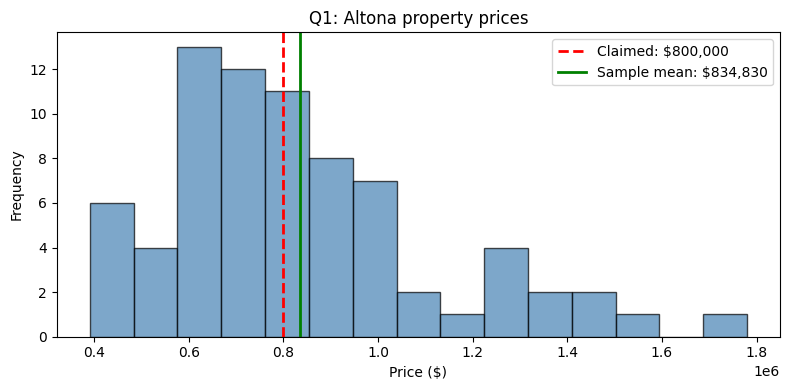

In [3]:
# Q1: Distribution of Altona prices vs claimed $800,000
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(altona, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(mu0, color='red', linestyle='--', linewidth=2, label=f'Claimed: ${mu0:,.0f}')
ax.axvline(altona.mean(), color='green', linestyle='-', linewidth=2, label=f'Sample mean: ${altona.mean():,.0f}')
ax.set_xlabel('Price ($)')
ax.set_ylabel('Frequency')
ax.set_title('Q1: Altona property prices')
ax.legend()
plt.tight_layout()
plt.show()

---
## Question 2: 2016 – Difference in prices: Summer vs Winter (α = 5%)

Winter = Oct–Mar; Summer = Apr–Sep.

In [4]:
df_2016 = df[df['Date'].dt.year == 2016].copy()
df_2016['Month'] = df_2016['Date'].dt.month
df_2016['Season'] = df_2016['Month'].apply(lambda m: 'Winter' if m in [10,11,12,1,2,3] else 'Summer')

winter = df_2016[df_2016['Season'] == 'Winter']['Price'].dropna()
summer = df_2016[df_2016['Season'] == 'Summer']['Price'].dropna()

t_stat, p_val = stats.ttest_ind(summer, winter, equal_var=False)
alpha = 0.05

print(f'Summer (Apr-Sep) n={len(summer)}, mean=${summer.mean():,.0f}')
print(f'Winter (Oct-Mar) n={len(winter)}, mean=${winter.mean():,.0f}')
print(f't-statistic: {t_stat:.4f}, p-value: {p_val:.4f}')
print(f'Conclusion: {"Reject H0" if p_val < alpha else "Do not reject H0"} – significant difference in 2016 prices between summer and winter.' if p_val < alpha else 'No significant difference.')

Summer (Apr-Sep) n=4036, mean=$1,048,055
Winter (Oct-Mar) n=2300, mean=$1,116,648
t-statistic: -3.9211, p-value: 0.0001
Conclusion: Reject H0 – significant difference in 2016 prices between summer and winter.


---
## Question 3: Abbotsford – P(exactly 3 of 10 sold have no car parking)

Use column **Car**. No car = Car == 0.

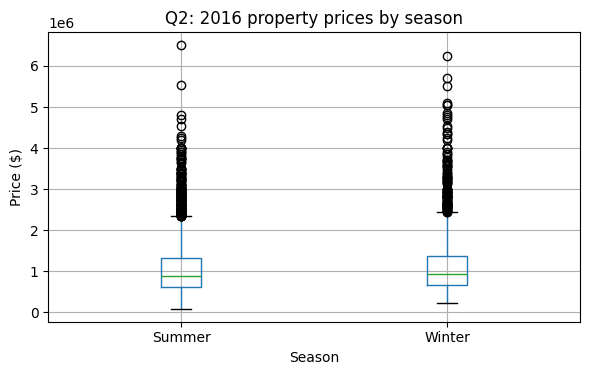

In [5]:
# Q2: Summer vs Winter 2016 price comparison
fig, ax = plt.subplots(figsize=(6, 4))
df_2016.boxplot(column='Price', by='Season', ax=ax)
ax.set_title('Q2: 2016 property prices by season')
ax.set_xlabel('Season')
ax.set_ylabel('Price ($)')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [6]:
abb = df[df['Suburb'] == 'Abbotsford']
p_no_car = (abb['Car'] == 0).mean()
n, k = 10, 3
prob = stats.binom.pmf(k, n, p_no_car)
print(f'Abbotsford: P(no car) = {p_no_car:.4f}')
print(f'P(X=3 out of 10 have no car) = {prob:.3f}')

Abbotsford: P(no car) = 0.2679
P(X=3 out of 10 have no car) = 0.260


---
## Question 4: Abbotsford – P(property with 3 rooms)

In [7]:
abb = df[df['Suburb'] == 'Abbotsford']
p_3_rooms = (abb['Rooms'] == 3).mean()
print(f'P(3 rooms in Abbotsford) = {p_3_rooms:.3f}')

P(3 rooms in Abbotsford) = 0.357


---
## Question 5: Abbotsford – P(property with 2 bathrooms)

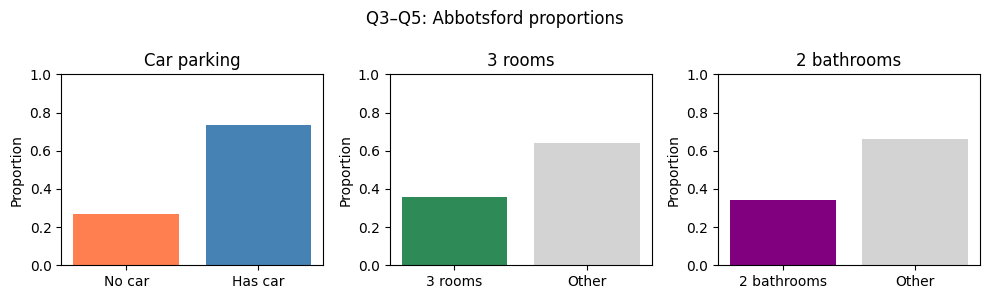

In [8]:
# Q3–Q5: Abbotsford – proportions (car, rooms, bathrooms)
abb = df[df['Suburb'] == 'Abbotsford']
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].bar(['No car', 'Has car'], [(abb['Car']==0).mean(), (abb['Car']>0).mean()], color=['coral','steelblue'])
axes[0].set_title('Car parking')
axes[1].bar(['3 rooms', 'Other'], [(abb['Rooms']==3).mean(), (abb['Rooms']!=3).mean()], color=['seagreen','lightgray'])
axes[1].set_title('3 rooms')
axes[2].bar(['2 bathrooms', 'Other'], [(abb['Bathroom']==2).mean(), (abb['Bathroom']!=2).mean()], color=['purple','lightgray'])
axes[2].set_title('2 bathrooms')
for ax in axes: ax.set_ylabel('Proportion'); ax.set_ylim(0, 1)
plt.suptitle('Q3–Q5: Abbotsford proportions')
plt.tight_layout()
plt.show()

In [9]:
abb = df[df['Suburb'] == 'Abbotsford']
p_2_bath = (abb['Bathroom'] == 2).mean()
print(f'P(2 bathrooms in Abbotsford) = {p_2_bath:.3f}')

P(2 bathrooms in Abbotsford) = 0.339


---
## Question 6: Richmond – One-Sample Test (Claim: average = $1,000,000, α = 5%)

In [10]:
richmond = df[df['Suburb'] == 'Richmond']['Price'].dropna()
mu0 = 1_000_000
alpha = 0.05

t_stat, p_val = stats.ttest_1samp(richmond, mu0)

print('H0: μ = $1,000,000')
print('H1: μ ≠ $1,000,000 (two-tailed)')
print(f'Test statistic (t): {t_stat:.4f}')
print(f'p-value: {p_val:.4f}')
print(f'Conclusion: {"Reject H0" if p_val < alpha else "Do not reject H0"} at α=0.05.')
print(f'Business: The actual average price in Richmond is {"significantly different" if p_val < alpha else "not significantly different"} from $1,000,000.')

H0: μ = $1,000,000
H1: μ ≠ $1,000,000 (two-tailed)
Test statistic (t): 2.5795
p-value: 0.0104
Conclusion: Reject H0 at α=0.05.
Business: The actual average price in Richmond is significantly different from $1,000,000.


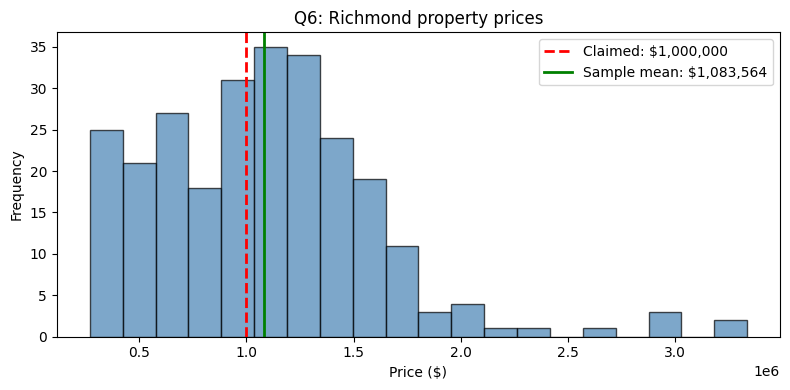

In [11]:
# Q6: Richmond price distribution vs claimed $1,000,000
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(richmond, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(1_000_000, color='red', linestyle='--', linewidth=2, label='Claimed: $1,000,000')
ax.axvline(richmond.mean(), color='green', linestyle='-', linewidth=2, label=f'Sample mean: ${richmond.mean():,.0f}')
ax.set_xlabel('Price ($)')
ax.set_ylabel('Frequency')
ax.set_title('Q6: Richmond property prices')
ax.legend()
plt.tight_layout()
plt.show()

---
## Question 7: Independent Two-Sample T-Test – Car parking vs price (α = 5%)

In [12]:
with_car = df[df['Car'] > 0]['Price'].dropna()
no_car = df[df['Car'] == 0]['Price'].dropna()

t_stat, p_val = stats.ttest_ind(with_car, no_car, alternative='greater', equal_var=False)
alpha = 0.05

print('Choice of test: Independent two-sample t-test (Welch); one-tailed (with car > no car).')
print(f'With car: n={len(with_car)}, mean=${with_car.mean():,.0f}')
print(f'No car:   n={len(no_car)}, mean=${no_car.mean():,.0f}')
print(f't-statistic: {t_stat:.4f}, p-value: {p_val:.4f}')
print(f'Interpretation: p-value {"<" if p_val < alpha else ">="} α → {"Reject H0" if p_val < alpha else "Do not reject H0"}.')
print('Business: Properties with car parking sell at a higher average price.' if p_val < alpha else 'Business: No evidence that car parking increases average price.')

Choice of test: Independent two-sample t-test (Welch); one-tailed (with car > no car).
With car: n=12492, mean=$1,074,444
No car:   n=1026, mean=$1,079,088
t-statistic: -0.2722, p-value: 0.6073
Interpretation: p-value >= α → Do not reject H0.
Business: No evidence that car parking increases average price.


C:\Users\p154kuma\AppData\Local\Temp\ipykernel_58664\2089350968.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([no_car, with_car], labels=['No car parking', 'With car parking'], patch_artist=True)


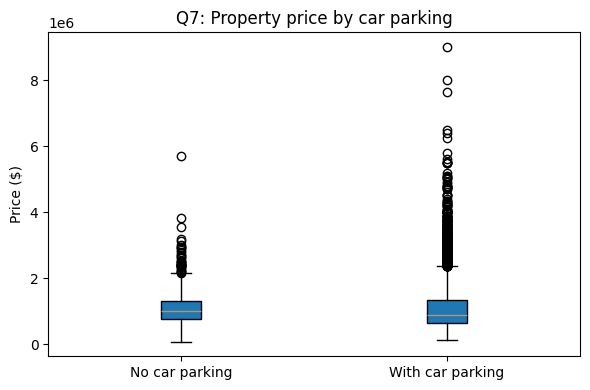

In [13]:
# Q7: Price by car parking (with vs without)
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([no_car, with_car], labels=['No car parking', 'With car parking'], patch_artist=True)
ax.set_ylabel('Price ($)')
ax.set_title('Q7: Property price by car parking')
plt.tight_layout()
plt.show()

---
## Question 8: Two-Way ANOVA – Suburb & Property Type effects on Price

In [14]:
# Use a subset of suburbs and types for interpretable ANOVA (otherwise too many levels)
suburbs_top = df['Suburb'].value_counts().head(8).index.tolist()
df_anova = df[df['Suburb'].isin(suburbs_top)].copy()
df_anova = df_anova[['Price', 'Suburb', 'Type']].dropna()

model = ols('Price ~ C(Suburb) + C(Type) + C(Suburb):C(Type)', data=df_anova).fit()
anova_table = anova_lm(model, typ=2)
print(anova_table)
print('\nFactors with p < 0.05 significantly affect price.')

                         sum_sq      df           F         PR(>F)
C(Suburb)          1.497541e+14     7.0  176.590070  4.521187e-202
C(Type)            1.863050e+14     2.0  768.918356  4.514059e-246
C(Suburb):C(Type)  3.837242e+13    14.0   22.624386   2.007013e-54
Residual           2.328454e+14  1922.0         NaN            NaN

Factors with p < 0.05 significantly affect price.


---
## Question 9: p-Value Interpretation (p = 0.032, α = 0.05)

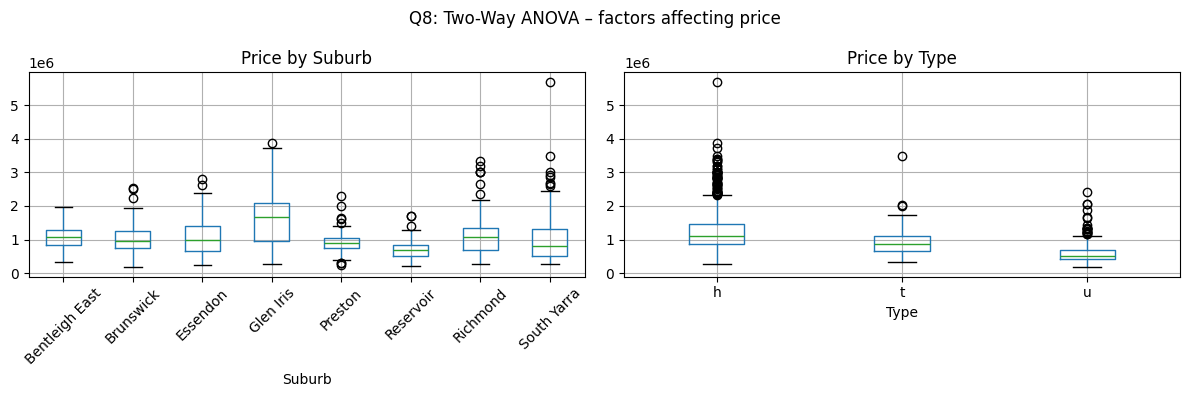

In [15]:
# Q8: Price by Suburb and Type (box plots)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_anova.boxplot(column='Price', by='Suburb', ax=axes[0], rot=45)
axes[0].set_title('Price by Suburb')
axes[0].set_xlabel('Suburb')
df_anova.boxplot(column='Price', by='Type', ax=axes[1])
axes[1].set_title('Price by Type')
axes[1].set_xlabel('Type')
plt.suptitle('Q8: Two-Way ANOVA – factors affecting price')
plt.tight_layout()
plt.show()

**What does this p-value indicate?**  
The p-value 0.032 is the probability of observing a difference in prices at least as extreme as in the sample, assuming the null hypothesis (no difference between suburbs) is true.

**Should the null hypothesis be rejected at α = 0.05?**  
Yes. Since 0.032 < 0.05, we reject the null hypothesis at the 5% significance level.

**Business interpretation:**  
There is statistically significant evidence of a difference in prices between the two suburbs. A stakeholder can conclude that location (suburb) is associated with price differences in this sample.

---
## Question 10: Industry-Style Hypothesis – Premium for >2 bathrooms (α = 5%)

In [16]:
premium = df[df['Bathroom'] > 2]['Price'].dropna()
standard = df[df['Bathroom'] <= 2]['Price'].dropna()

t_stat, p_val = stats.ttest_ind(premium, standard, alternative='greater', equal_var=False)
alpha = 0.05

print('Test: Independent two-sample t-test (one-tailed: premium > standard).')
print('H0: μ(>2 bathrooms) ≤ μ(≤2 bathrooms)')
print('H1: μ(>2 bathrooms) > μ(≤2 bathrooms)')
print(f'>2 bathrooms: n={len(premium)}, mean=${premium.mean():,.0f}')
print(f'≤2 bathrooms: n={len(standard)}, mean=${standard.mean():,.0f}')
print(f'p-value: {p_val:.4f}')
print(f'Recommendation: {"Support the policy claim" if p_val < alpha else "Do not support"}: properties with >2 bathrooms {"do" if p_val < alpha else "do not"} command a premium at α=0.05.')

Test: Independent two-sample t-test (one-tailed: premium > standard).
H0: μ(>2 bathrooms) ≤ μ(≤2 bathrooms)
H1: μ(>2 bathrooms) > μ(≤2 bathrooms)
>2 bathrooms: n=1060, mean=$1,882,824
≤2 bathrooms: n=12520, mean=$1,007,348
p-value: 0.0000
Recommendation: Support the policy claim: properties with >2 bathrooms do command a premium at α=0.05.


C:\Users\p154kuma\AppData\Local\Temp\ipykernel_58664\87577412.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([standard, premium], labels=['≤2 bathrooms', '>2 bathrooms'], patch_artist=True)


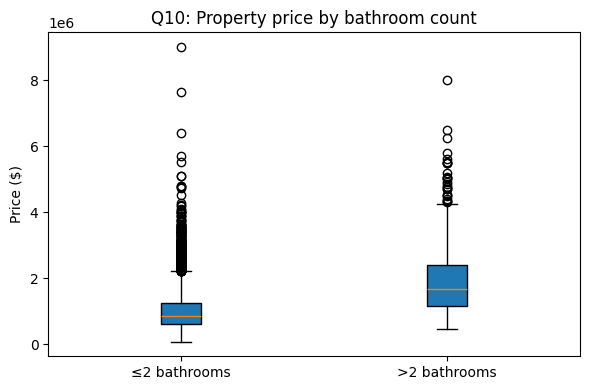

In [17]:
# Q10: Price by bathroom category (>2 vs ≤2)
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([standard, premium], labels=['≤2 bathrooms', '>2 bathrooms'], patch_artist=True)
ax.set_ylabel('Price ($)')
ax.set_title('Q10: Property price by bathroom count')
plt.tight_layout()
plt.show()